In [19]:
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

In [11]:
data = pd.read_csv("creditcard.csv")
print(data.head())
print(data.info())
print(data['Class'].value_counts())
x=data.drop('Class',axis=1)
y=data['Class']

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)
scale_pos_weight= len(y_train[y_train==0])/len(y_train[y_train==1])
print("Scale Pos Weight:", scale_pos_weight)
model=XGBClassifier(n_estimators=100,max_depth=5,learning_rate=0.2,scale_pos_weight=scale_pos_weight,eval_metric='auc', use_label_encoder=False)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))
roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_score)

Scale Pos Weight: 578.546511627907


C:\Users\juver\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:03:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[[85276    19]
 [   32   116]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.78      0.82       148

    accuracy                           1.00     85443
   macro avg       0.93      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC Score: 0.9672226992805573


In [20]:
joblib.dump(model, "fraud_model.pkl")
print("Model saved successfully!")

Model saved successfully!


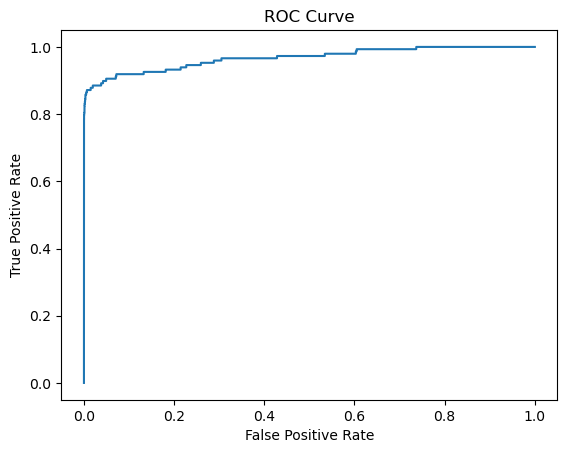

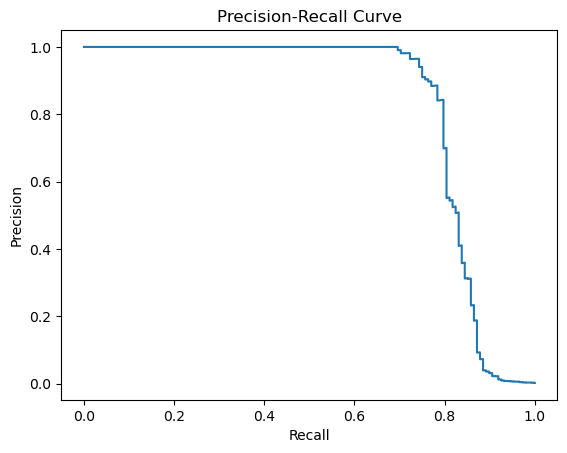

In [22]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()